In [1]:
# Step 1: Imports, global configuration, and environment check

import random
import time
from collections import deque, namedtuple
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

try:
    import gymnasium as gym
    from gymnasium.spaces import Discrete, Box
    print("Using gymnasium")
except ImportError:
    import gym
    from gym.spaces import Discrete, Box
    print("Using gym")

Using gymnasium


In [2]:
import os
import json
import pickle
import pandas as pd
from pathlib import Path
from dataclasses import asdict

In [3]:
# Device configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Reproducibility helper

def set_seed(seed: int):
    """
    Set random seeds for reproducibility.

    We will run each experiment with multiple seeds later,
    because the project requires results averaged across at least 3 seeds.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [5]:
# Available environments

ENVIRONMENTS = {
    "cartpole": "CartPole-v1",
    "mountaincar": "MountainCar-v0",
    "mountaincar_continuous": "MountainCarContinuous-v0",
    "acrobot": "Acrobot-v1",
    "pendulum": "Pendulum-v1",
}

# Select environment here
ENV_KEY = "cartpole"
ENV_NAME = ENVIRONMENTS[ENV_KEY]

In [6]:
# Environment inspection

def inspect_environment(env_name: str, seed: int = 0):
    """
    Create an environment and print useful information about it.
    This helps us check whether DQN can be applied directly.
    """
    env = gym.make(env_name)
    obs, info = env.reset(seed=seed)

    print("=" * 60)
    print("Environment:", env_name)
    print("Observation space:", env.observation_space)
    print("Action space:", env.action_space)
    print("Initial observation:", obs)

    is_discrete_action = isinstance(env.action_space, Discrete)
    is_vector_observation = isinstance(env.observation_space, Box) and len(env.observation_space.shape) == 1

    print("Vector observation:", is_vector_observation)
    print("Discrete action space:", is_discrete_action)

    if is_vector_observation:
        print("Observation dimension:", env.observation_space.shape[0])

    if is_discrete_action:
        print("Number of actions:", env.action_space.n)
        print("DQN compatibility: YES")
    else:
        print("DQN compatibility: NO, action space is continuous")
        print("Remark: For this environment, use PPO/SAC/TD3 or discretize actions.")

    env.close()


# Inspect all project environments
for env_name in ENVIRONMENTS.values():
    inspect_environment(env_name, seed=0)

Environment: CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
Vector observation: True
Discrete action space: True
Observation dimension: 4
Number of actions: 2
DQN compatibility: YES
Environment: MountainCar-v0
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)
Initial observation: [-0.47260767  0.        ]
Vector observation: True
Discrete action space: True
Observation dimension: 2
Number of actions: 3
DQN compatibility: YES
Environment: MountainCarContinuous-v0
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Box(-1.0, 1.0, (1,), float32)
Initial observation: [-0.47260767  0.        ]
Vector observation: True
Discrete action space: False
Observation dimension: 2
DQN compatibility: NO, action space is continuous
Remark:

## Creating the selected environment

We now define a helper function that creates a Gym environment and extracts the information needed by DQN.

This makes the notebook modular: later, we can change the environment name or seed without rewriting code.

DQN requires a **discrete action space** because the Q-network outputs one Q-value per possible action. Therefore, this function checks whether the selected environment is compatible with DQN.

For classic-control Gym environments, the observation is a vector, so we also extract the observation dimension.

In [7]:
def make_dqn_env(env_name: str, seed: int = 0):
    """
    Create a Gym/Gymnasium environment for DQN.

    Returns:
        env: the created environment
        obs_dim: size of the observation vector
        action_dim: number of discrete actions
    """
    set_seed(seed)

    env = gym.make(env_name)
    obs, info = env.reset(seed=seed)

    if not isinstance(env.action_space, Discrete):
        env.close()
        raise ValueError(
            f"{env_name} has a continuous action space. "
            "DQN cannot be applied directly without discretizing actions."
        )

    if not isinstance(env.observation_space, Box) or len(env.observation_space.shape) != 1:
        env.close()
        raise ValueError(
            f"{env_name} does not have a simple vector observation space. "
            "This notebook currently assumes vector observations."
        )

    obs_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    return env, obs_dim, action_dim

In [8]:
# Create selected environment
env, obs_dim, action_dim = make_dqn_env(ENV_NAME, seed=0)

print("Selected environment:", ENV_NAME)
print("Observation dimension:", obs_dim)
print("Number of actions:", action_dim)

env.close()

Selected environment: CartPole-v1
Observation dimension: 4
Number of actions: 2


We follow the paper closely, including:

## What we keep from the DQN paper

- **Q-learning objective**
  - Learn the action-value function:
    ```
    Q(state, action)
    ```

- **Q-network (function approximation)**
  - Use a neural network to approximate Q instead of a table.

- **One output per action**
  - The network outputs Q-values for all actions in a single forward pass:
    ```
    Q(s) → [Q(s,a₁), Q(s,a₂), ...]
    ```

- **ε-greedy exploration**
  - With probability ε: take a random action (exploration).
  - With probability 1 - ε: take the action with highest Q-value (exploitation).

- **ε annealing during training**
  - Start with high ε (more exploration).
  - Decrease ε over time.
  - Keep a small ε later to maintain some exploration.

- **Experience replay**
  - Store transitions:
    ```
    (state, action, reward, next_state, done)
    ```
  - Reuse past experiences multiple times → improves data efficiency.

- **Uniform random sampling from replay buffer**
  - Sample minibatches randomly → breaks correlation between consecutive samples → more stable training.

- **Minibatch updates**
  - Train using small batches instead of single transitions → smoother gradient updates.

- **Batch size = 32**
  - Same value used in the paper.

- **Bellman target**
  - If terminal:
    ```
    y = reward
    ```
  - If not terminal:
    ```
    y = reward + γ max Q(next_state, next_action)
    ```

- **Squared TD error loss**
  - Minimize:
    ```
    (target - predicted Q)²
    ```

- **Stop-gradient on target**
  - The target is treated as fixed during backpropagation → prevents instability.

- **RMSProp optimizer**
  - Same optimizer used in the paper.

- **Online interaction**
  - The agent learns while interacting with the environment:
    ```
    act → collect data → train → repeat
    ```

- **Off-policy learning**
  - The agent learns from replay memory containing data generated by older policies.

- **Periodic evaluation**
  - Evaluate performance during training, not only at the end.

- **Average episode return as main metric**
  - Performance is measured as:
    ```
    total reward per episode
    ```
  - Then averaged over multiple episodes.


## Differences from the paper
- The input to the network are vector observations instead of raw pixels:
    - The paper uses Atari screenshots, so the input is high-dimensional image data.
    - Gym classic-control environments give compact numerical states, such as position, velocity, and angle.
    - Therefore, we feed the observation vector directly to the network.
- No image preprocessing:
    - The paper converts RGB images to grayscale, resizes them, and crops them to reduce computation.
    - Gym observations are already low-dimensional vectors, so image preprocessing is unnecessary.
- No frame stacking
    - The paper stacks 4 frames because one image does not show motion.
    - Gym observations usually already include velocity terms.
    - Example: CartPole gives cart velocity and pole angular velocity, so one observation already contains motion information.
- MLP instead of CNN:
    - The paper uses a CNN because images have spatial structure: nearby pixels are related.
    - Gym states are small vectors, not images.
    - A fully connected MLP is simpler, cheaper, and appropriate for vector input.
- No frame skipping
  - The paper uses frame skipping mainly because Atari uses image frames and CNN inference is expensive.
  - Repeating one action for several frames reduces the number of costly CNN forward passes.
  - Atari video frames are also highly correlated, so choosing a new action every single frame is often unnecessary.
  - In Gym classic-control tasks, the input is a small vector and the MLP is very cheap to evaluate.
  - These tasks often need precise step-by-step control, so repeating the same action for multiple steps could hurt performance.
  - Therefore, we choose a new action at every environment step.
- Smaller replay buffer
  - The paper uses a very large replay memory because Atari training produces millions of image frames.
  - Atari observations are high-dimensional and the agent needs many diverse situations to learn useful visual patterns.
  - In Gym classic-control tasks, observations are small vectors, not images.
  - The environments are also much simpler, so the agent does not need millions of stored transitions to get useful coverage of the state space.
  - A smaller buffer, such as 50,000 or 100,000 transitions, is usually enough to keep diverse past experiences.
  - Keeping the buffer smaller also makes sampling faster and avoids storing too many outdated early experiences from a very bad random policy.
  - The key idea from the paper remains the same: store past transitions and sample them randomly for stable minibatch learning.
- Training measured in environment steps, not frames
    - In Atari, a frame is one image from the game.
    - In Gym classic control, one step means: choose action → environment updates → receive reward and next state
    - Since there are no image frames, environment steps are the natural training unit.
- Reward clipping not used by default:
    - The paper clips rewards to -1, 0, or +1 because Atari games have very different score scales.
    - Clipping keeps Bellman targets smaller, which makes gradients smaller and training more stable across games.
    - Gym rewards are already small and similarly scaled, so clipping is less necessary. Starting with raw rewards preserves useful reward information.
    - During evaluation, we use a greedy policy with ε = 0.0. This measures the learned policy without adding random exploratory actions. In the paper, they set ε = 0.05 for evaluation.

## DQN Hyperparameters (configurable)

In [9]:
@dataclass
class DQNConfig:
    # Training
    total_steps: int = 100_000
    batch_size: int = 32
    
    # Replay buffer
    buffer_size: int = 50_000
    
    # Discount factor
    gamma: float = 0.99
    
    # Learning rate
    lr: float = 1e-3
    
    # Epsilon-greedy (paper-style annealing)
    epsilon_start: float = 1.0
    epsilon_end: float = 0.1
    epsilon_decay_steps: int = 30_000
    
    # Evaluation
    eval_interval: int = 5_000
    eval_episodes: int = 5
    eval_epsilon: float = 0.00
    
    # Network
    hidden_dim: int = 128
    
    # Training start
    learning_starts: int = 1_000


config = DQNConfig()
print(config)

DQNConfig(total_steps=100000, batch_size=32, buffer_size=50000, gamma=0.99, lr=0.001, epsilon_start=1.0, epsilon_end=0.1, epsilon_decay_steps=30000, eval_interval=5000, eval_episodes=5, eval_epsilon=0.0, hidden_dim=128, learning_starts=1000)


In [10]:
ALGORITHM_NAME = "DQN"
RESULTS_DIR = Path("results") / ALGORITHM_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Replay Buffer / Experience Replay

The replay buffer is one of the key ideas used in the DQN paper.

At every environment step, the agent stores one transition:


(state, action, reward, next_state, done)


Later, instead of training only on the most recent transition, we sample a random minibatch from this memory.

This follows the paper because:
- it reuses past experience multiple times,
- it breaks correlation between consecutive environment steps,
- it makes training more stable.

Small difference from the paper:
- the paper stores Atari frame-based transitions,
- here we store Gym vector-state transitions.

In [11]:
Transition = namedtuple(
    "Transition",
    ["state", "action", "reward", "next_state", "done"]
)

In [12]:
class ReplayBuffer:
    def __init__(self, capacity: int):
        """
        Fixed-size replay buffer.

        Args:
            capacity: maximum number of transitions stored.
                      When full, the oldest transitions are removed.
        """
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """
        Store one transition in replay memory.
        """
        transition = Transition(state, action, reward, next_state, done)
        self.buffer.append(transition)

    def sample(self, batch_size: int):
        """
        Randomly sample a minibatch of transitions.
        """
        transitions = random.sample(self.buffer, batch_size)

        states = np.array([t.state for t in transitions], dtype=np.float32)
        actions = np.array([t.action for t in transitions], dtype=np.int64)
        rewards = np.array([t.reward for t in transitions], dtype=np.float32)
        next_states = np.array([t.next_state for t in transitions], dtype=np.float32)
        dones = np.array([t.done for t in transitions], dtype=np.float32)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

## Q-Network Architecture

In the DQN paper, the Q-function is approximated by a neural network.

The paper uses a CNN because Atari observations are images:


84 × 84 × 4 image → CNN → Q-values


In our Gym setting, observations are small numerical vectors, so we use an MLP:


state vector → fully connected layers → Q-values


The key idea remains exactly the same as in the paper:

- the network receives the current state,
- it outputs one Q-value for each possible discrete action,
- the agent chooses the action with the highest Q-value unless it explores randomly.

For example, in CartPole:


input: [cart position, cart velocity, pole angle, pole angular velocity]
output: [Q(left), Q(right)]


We use ReLU activations, following the paper's use of rectifier nonlinearities

In [13]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 128):
        """
        MLP Q-network for vector observations.

        Args:
            obs_dim: dimension of the observation vector
            action_dim: number of discrete actions
            hidden_dim: number of hidden units
        """
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        """
        Forward pass.

        Input:
            x: batch of states, shape (batch_size, obs_dim)

        Output:
            Q-values, shape (batch_size, action_dim)
        """
        return self.net(x)

## ε-greedy action selection

DQN does not always choose the action with the highest predicted Q-value during training.

Instead, it uses an ε-greedy policy:

- with probability ε: choose a random action,
- with probability 1 - ε: choose the action with the highest Q-value.

This follows the DQN paper.

The paper starts with high exploration:


ε = 1.0


and gradually decreases it to:


ε = 0.1


For our Gym version, we anneal ε over environment steps instead of Atari frames.

During evaluation, we will use a fixed small ε, such as:


ε = 0.05


This is close to the paper's evaluation setup.

In [14]:
def linear_epsilon(step: int, config: DQNConfig) -> float:
    """
    Linearly anneal epsilon from epsilon_start to epsilon_end.

    After epsilon_decay_steps, epsilon stays fixed at epsilon_end.
    """
    if step >= config.epsilon_decay_steps:
        return config.epsilon_end

    fraction = step / config.epsilon_decay_steps
    epsilon = config.epsilon_start + fraction * (config.epsilon_end - config.epsilon_start)

    return epsilon

In [15]:
def select_action(q_network, state, action_dim: int, epsilon: float, device):
    """
    Select an action using epsilon-greedy exploration.

    Args:
        q_network: the Q-network
        state: current observation vector
        action_dim: number of discrete actions
        epsilon: exploration probability
        device: CPU or GPU

    Returns:
        action: integer action
    """
    if random.random() < epsilon:
        return random.randrange(action_dim)

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        q_values = q_network(state_tensor)
        action = torch.argmax(q_values, dim=1).item()

    return action

In [16]:
# Sanity check for epsilon schedule

for step in [0, config.epsilon_decay_steps // 4, config.epsilon_decay_steps // 2,
             config.epsilon_decay_steps, config.epsilon_decay_steps + 10_000]:
    print(f"step={step:6d} | epsilon={linear_epsilon(step, config):.3f}")

step=     0 | epsilon=1.000
step=  7500 | epsilon=0.775
step= 15000 | epsilon=0.550
step= 30000 | epsilon=0.100
step= 40000 | epsilon=0.100


In [17]:
# Sanity check for action selection

env, obs_dim, action_dim = make_dqn_env(ENV_NAME, seed=0)
state, info = env.reset(seed=0)

q_net = QNetwork(obs_dim, action_dim, config.hidden_dim).to(device)

epsilon = 1.0
actions = [select_action(q_net, state, action_dim, epsilon, device) for _ in range(10)]

print("Actions with epsilon=1.0:")
print(actions)

epsilon = 0.0
actions = [select_action(q_net, state, action_dim, epsilon, device) for _ in range(10)]

print("Actions with epsilon=0.0:")
print(actions)

env.close()

Actions with epsilon=1.0:
[1, 1, 1, 1, 0, 1, 0, 1, 0, 0]
Actions with epsilon=0.0:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## DQN update step

Now we implement the neural network update.

This is the part where DQN learns from replay memory.

For each minibatch transition:


(state, action, reward, next_state, done)


we compute the Bellman target.

If the transition ended the episode:


target = reward


If the episode continued:


target = reward + γ max Q(next_state, next_action)


Then we compare this target with the Q-network prediction for the action actually taken:


prediction = Q(state, action_taken)


The loss is:


(target - prediction)^2


This follows the DQN paper.

Important detail:
The target is treated as fixed during backpropagation. In PyTorch, we do this using:


with torch.no_grad():


This means the network is updated only through the prediction, not through the target.

In [18]:
def dqn_update(q_network, optimizer, replay_buffer, config: DQNConfig, device):
    """
    Perform one DQN update using a random minibatch from replay memory.

    This follows the paper-style DQN update:
        target = r + gamma * max_a Q(next_state, a)

    The target is treated as fixed during backpropagation.
    """

    if len(replay_buffer) < config.batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(config.batch_size)

    states = torch.tensor(states, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
    next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
    dones = torch.tensor(dones, dtype=torch.float32, device=device)

    # Q-values for all actions in current states
    q_values = q_network(states)

    # Select Q-value of the action actually taken
    predicted_q = q_values.gather(1, actions).squeeze(1)

    # Compute Bellman target
    with torch.no_grad():
        next_q_values = q_network(next_states)
        max_next_q = next_q_values.max(dim=1).values

        targets = rewards + config.gamma * max_next_q * (1.0 - dones)

    # Squared TD error loss
    loss = nn.functional.mse_loss(predicted_q, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

## Full DQN training loop

We now combine everything:

- environment interaction
- ε-greedy action selection
- replay buffer storage
- DQN updates
- episode handling
- periodic evaluation

This is the core loop of DQN.

This follows the paper:


act → store transition → sample minibatch → update network → repeat


Differences from the paper:

- We use **environment steps** instead of frames
- We evaluate every fixed number of steps instead of "epochs"
- We use vector states instead of image inputs

Key idea:
Training happens continuously while the agent interacts with the environment.

In [19]:
def evaluate_policy(env_name, q_network, config, device, seed=0):
    """
    Evaluate the current policy.

    This function creates a separate evaluation environment,
    but it does not reset global training randomness.
    """
    env = gym.make(env_name)

    if not isinstance(env.action_space, Discrete):
        env.close()
        raise ValueError(f"{env_name} has a continuous action space.")

    action_dim = env.action_space.n
    returns = []

    for episode_idx in range(config.eval_episodes):
        state, info = env.reset(seed=seed + episode_idx)
        done = False
        total_reward = 0

        while not done:
            action = select_action(
                q_network,
                state,
                action_dim,
                epsilon=config.eval_epsilon,
                device=device
            )

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            total_reward += reward
            state = next_state

        returns.append(total_reward)

    env.close()
    return np.mean(returns)

In [20]:
def train_dqn(env_name, config: DQNConfig, seed: int = 0):
    """
    Train DQN on a given environment.
    """

    set_seed(seed)

    env, obs_dim, action_dim = make_dqn_env(env_name, seed)

    q_net = QNetwork(obs_dim, action_dim, config.hidden_dim).to(device)
    optimizer = optim.RMSprop(q_net.parameters(), lr=config.lr)

    replay_buffer = ReplayBuffer(config.buffer_size)

    state, info = env.reset(seed=seed)

    episode_return = 0
    episode_returns = []
    eval_returns = []
    losses = []

    for step in range(config.total_steps):

        # Epsilon schedule
        epsilon = linear_epsilon(step, config)

        # Select action
        action = select_action(q_net, state, action_dim, epsilon, device)

        # Environment step
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Store transition
        replay_buffer.push(state, action, reward, next_state, done)

        episode_return += reward

        # Training update
        if step > config.learning_starts:
            loss = dqn_update(q_net, optimizer, replay_buffer, config, device)
            if loss is not None:
                losses.append(loss)

        # Move to next state
        state = next_state

        # Handle episode end
        if done:
            episode_returns.append(episode_return)
            episode_return = 0
            state, info = env.reset()

        # Periodic evaluation
        if step % config.eval_interval == 0:
            eval_return = evaluate_policy(env_name, q_net, config, device, seed)
            eval_returns.append((step, eval_return))
            print(f"Step {step} | Eval return: {eval_return:.2f} | Epsilon: {epsilon:.3f}")

    env.close()

    return {
        "episode_returns": episode_returns,
        "eval_returns": eval_returns,
        "losses": losses,
        "q_network": q_net
    }

## Multi-seed training and aggregation

Reinforcement learning results are noisy because of randomness:

- network initialization
- exploration (ε-greedy)
- environment stochasticity
- minibatch sampling

Therefore, a single run is not reliable.

To obtain meaningful results, we:

- train the same algorithm multiple times with different random seeds
- record evaluation performance for each run
- average the results across seeds

This follows the project requirement:


Each plot must report performance averaged across at least 3 seeds.


We will:
- run training for several seeds
- collect evaluation curves
- align them by training step
- compute mean performance

In [21]:
def run_multiple_seeds(env_name, config, seeds):
    """
    Train DQN with multiple seeds.

    Returns:
        all_results: list of results dictionaries
    """
    all_results = []

    for seed in seeds:
        print(f"\n===== Training with seed {seed} =====")
        results = train_dqn(env_name, config, seed)
        all_results.append(results)

    return all_results

In [22]:
def extract_eval_curves(all_results):
    """
    Extract evaluation returns aligned by step.

    Returns:
        steps: list of evaluation steps
        eval_matrix: shape (num_seeds, num_points)
    """
    # Assume all runs evaluated at same steps
    steps = [step for step, _ in all_results[0]["eval_returns"]]

    eval_matrix = []

    for results in all_results:
        values = [val for _, val in results["eval_returns"]]
        eval_matrix.append(values)

    eval_matrix = np.array(eval_matrix)

    return steps, eval_matrix

In [23]:
def compute_statistics(eval_matrix):
    """
    Compute mean and standard deviation across seeds.
    """
    mean = np.mean(eval_matrix, axis=0)
    std = np.std(eval_matrix, axis=0)

    return mean, std

## Plotting learning curves

Now we plot the DQN evaluation performance.

For each seed, we evaluated the policy periodically during training.

We now plot:


x-axis: environment steps
y-axis: average evaluation return


The main curve is the mean across seeds.

The shaded region shows variability across seeds using standard deviation.

This is important for the project because each plot should report performance av

In [24]:
def plot_eval_curve(steps, mean, std, title=None, save_path=None):
    """
    Plot mean evaluation return with standard deviation shading.
    """
    steps = np.array(steps)

    plt.figure(figsize=(8, 5))

    plt.plot(steps, mean, label="Mean evaluation return")
    plt.fill_between(
        steps,
        mean - std,
        mean + std,
        alpha=0.2,
        label="±1 std across seeds"
    )

    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")
    
    if title is None:
        title = f"DQN on {ENV_NAME}"
        
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [25]:
def plot_individual_seed_curves(steps, eval_matrix, title=None, save_path=None):
    """
    Plot evaluation curves for each seed separately.
    """
    steps = np.array(steps)

    plt.figure(figsize=(8, 5))

    for seed_idx in range(eval_matrix.shape[0]):
        plt.plot(steps, eval_matrix[seed_idx], alpha=0.6, label=f"Seed {seed_idx}")

    plt.xlabel("Environment steps")
    plt.ylabel("Average episode return")

    if title is None:
        title = f"DQN individual seed curves on {ENV_NAME}"

    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

Helper functions to save the plots:

In [26]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "wb") as f:
        pickle.dump(obj, f)


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w") as f:
        json.dump(obj, f, indent=4)


def save_eval_curve_csv(steps, eval_matrix, mean, std, path):
    """
    Save evaluation curves in a format that can be loaded later
    to compare DQN with other algorithms.
    """
    data = {
        "step": steps,
        "mean_return": mean,
        "std_return": std,
    }

    for seed_idx in range(eval_matrix.shape[0]):
        data[f"seed_{seed_idx}_return"] = eval_matrix[seed_idx]

    df = pd.DataFrame(data)

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

    return df


def save_trained_model(q_network, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    torch.save(q_network.state_dict(), path)

## Hyperparameter experiments

The project asks us not only to report the best final result, but also to study which implementation details and hyperparameters matter.

For DQN, useful hyperparameters to test include:

- learning rate
- replay buffer size
- epsilon decay speed
- network size
- discount factor γ
- reward clipping

We will create a helper function that runs one hyperparameter experiment by changing only one setting at a time.

This is important for fair comparison: if we change many things at once, we cannot know which change caused the performance difference.

In [27]:
def make_config(**kwargs):
    """
    Create a DQNConfig while overriding selected hyperparameters.

    Example:
        config = make_config(lr=5e-4, total_steps=50_000)
    """
    base_config = DQNConfig()

    for key, value in kwargs.items():
        if not hasattr(base_config, key):
            raise ValueError(f"Unknown config parameter: {key}")
        setattr(base_config, key, value)

    return base_config

In [28]:
def run_hyperparameter_comparison(env_name, experiment_name, configs, seeds):
    """
    Run several DQN configurations and store their results.

    Args:
        env_name: Gym environment name
        experiment_name: name of the experiment
        configs: dictionary mapping label -> DQNConfig
        seeds: list of random seeds

    Returns:
        comparison_results: dictionary with aggregated results
    """
    comparison_results = {}

    for label, config in configs.items():
        print(f"\n========== {experiment_name}: {label} ==========")

        all_results = run_multiple_seeds(env_name, config, seeds)
        steps, eval_matrix = extract_eval_curves(all_results)
        mean, std = compute_statistics(eval_matrix)

        comparison_results[label] = {
            "steps": steps,
            "eval_matrix": eval_matrix,
            "mean": mean,
            "std": std,
            "config": config,
            "all_results": all_results,
        }

    return comparison_results

In [29]:
def plot_hyperparameter_comparison(comparison_results, title, save_path=None):
    """
    Plot mean evaluation return for multiple hyperparameter settings.
    """
    plt.figure(figsize=(9, 5))

    for label, result in comparison_results.items():
        steps = np.array(result["steps"])
        mean = result["mean"]
        std = result["std"]

        plt.plot(steps, mean, label=label)
        plt.fill_between(steps, mean - std, mean + std, alpha=0.15)

    plt.xlabel("Environment steps")
    plt.ylabel("Average evaluation return")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


## Grid search for DQN hyperparameters

The project asks us not to report only the final best hyperparameters.

Therefore, we run a small grid search and save the performance of the best tested configuratio, then we vary hyperparameters around it to see their effect one by one.

In [30]:
from itertools import product

def build_config_grid(base_config, grid):
    keys = list(grid.keys())
    values = list(grid.values())

    configs = {}

    for combination in product(*values):
        config = DQNConfig(**base_config.__dict__)
        label_parts = []

        for key, value in zip(keys, combination):
            setattr(config, key, value)
            label_parts.append(f"{key}={value}")

        label = ", ".join(label_parts)
        configs[label] = config

    return configs


def summarize_results(results_dict):
    summary = []

    for label, result in results_dict.items():
        final_values = result["eval_matrix"][:, -1]

        summary.append({
            "config": label,
            "final_mean": np.mean(final_values),
            "final_std": np.std(final_values),
            "best_mean_during_training": np.max(result["mean"])
        })

    return sorted(summary, key=lambda x: x["final_mean"], reverse=True)


def make_variation_configs(best_config, param_name, values):
    configs = {}

    for value in values:
        config = DQNConfig(**best_config.__dict__)
        setattr(config, param_name, value)

        label = f"{param_name} = {value}"
        configs[label] = config

    return configs

In [31]:
def remove_networks_from_results(results_dict):
    """
    Remove trained neural networks from grid/sensitivity results
    before saving them, because they are large and not needed
    for plotting.
    """
    cleaned = {}

    for label, result in results_dict.items():
        cleaned_result = result.copy()
        cleaned_all_results = []

        for seed_result in result["all_results"]:
            seed_result_clean = seed_result.copy()
            seed_result_clean.pop("q_network", None)
            cleaned_all_results.append(seed_result_clean)

        cleaned_result["all_results"] = cleaned_all_results
        cleaned[label] = cleaned_result

    return cleaned


####################################################################################################
Running DQN experiments on CartPole-v1
####################################################################################################
Number of configs: 6
Total runs: 18

========== DQN grid search: lr=0.0001, gamma=0.99, epsilon_decay_steps=30000, hidden_dim=128, buffer_size=50000 ==========

===== Training with seed 0 =====
Step 0 | Eval return: 9.40 | Epsilon: 1.000
Step 5000 | Eval return: 269.60 | Epsilon: 0.850
Step 10000 | Eval return: 330.20 | Epsilon: 0.700
Step 15000 | Eval return: 276.60 | Epsilon: 0.550
Step 20000 | Eval return: 317.70 | Epsilon: 0.400
Step 25000 | Eval return: 270.90 | Epsilon: 0.250
Step 30000 | Eval return: 254.80 | Epsilon: 0.100
Step 35000 | Eval return: 264.70 | Epsilon: 0.100
Step 40000 | Eval return: 214.80 | Epsilon: 0.100
Step 45000 | Eval return: 245.90 | Epsilon: 0.100
Step 50000 | Eval return: 231.60 | Epsilon: 0.100
Step 55000 | Eval ret

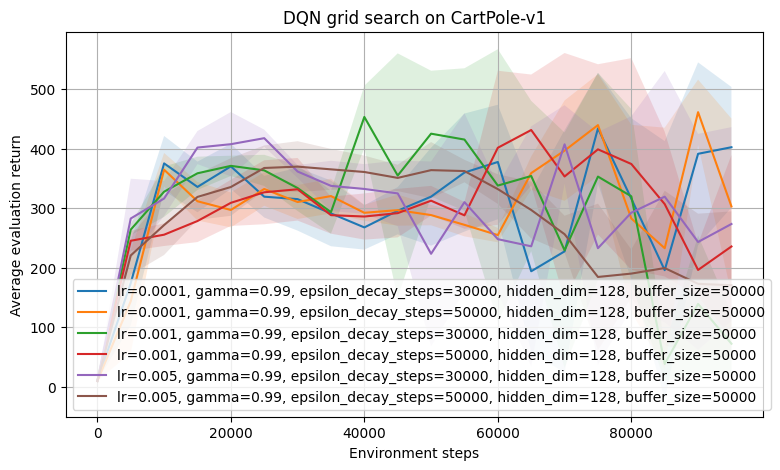


===== Training with seed 0 =====
Step 0 | Eval return: 9.40 | Epsilon: 1.000
Step 5000 | Eval return: 269.60 | Epsilon: 0.850
Step 10000 | Eval return: 330.20 | Epsilon: 0.700
Step 15000 | Eval return: 276.60 | Epsilon: 0.550
Step 20000 | Eval return: 317.70 | Epsilon: 0.400
Step 25000 | Eval return: 270.90 | Epsilon: 0.250
Step 30000 | Eval return: 254.80 | Epsilon: 0.100
Step 35000 | Eval return: 264.70 | Epsilon: 0.100
Step 40000 | Eval return: 214.80 | Epsilon: 0.100
Step 45000 | Eval return: 245.90 | Epsilon: 0.100
Step 50000 | Eval return: 231.60 | Epsilon: 0.100
Step 55000 | Eval return: 295.90 | Epsilon: 0.100
Step 60000 | Eval return: 264.90 | Epsilon: 0.100
Step 65000 | Eval return: 25.00 | Epsilon: 0.100
Step 75000 | Eval return: 500.00 | Epsilon: 0.100
Step 80000 | Eval return: 158.60 | Epsilon: 0.100
Step 85000 | Eval return: 77.80 | Epsilon: 0.100
Step 90000 | Eval return: 500.00 | Epsilon: 0.100
Step 95000 | Eval return: 262.80 | Epsilon: 0.100

===== Training with seed

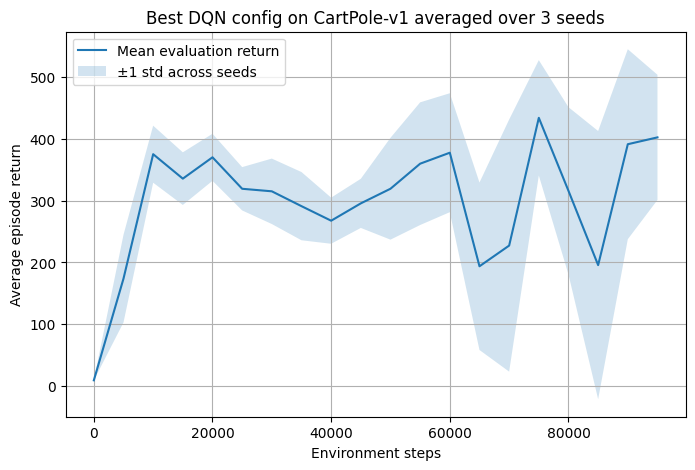

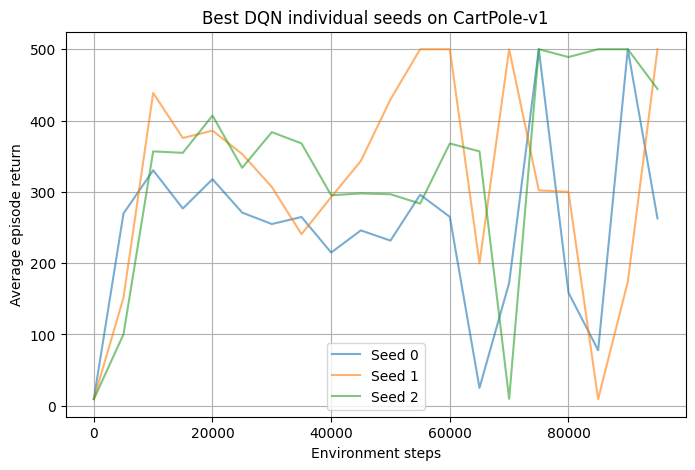



===== Learning rate sensitivity on CartPole-v1 =====

========== Learning rate: lr = 0.0001 ==========

===== Training with seed 0 =====
Step 0 | Eval return: 9.40 | Epsilon: 1.000
Step 5000 | Eval return: 269.60 | Epsilon: 0.850
Step 10000 | Eval return: 330.20 | Epsilon: 0.700
Step 15000 | Eval return: 276.60 | Epsilon: 0.550
Step 20000 | Eval return: 317.70 | Epsilon: 0.400
Step 25000 | Eval return: 270.90 | Epsilon: 0.250
Step 30000 | Eval return: 254.80 | Epsilon: 0.100
Step 35000 | Eval return: 264.70 | Epsilon: 0.100
Step 40000 | Eval return: 214.80 | Epsilon: 0.100
Step 45000 | Eval return: 245.90 | Epsilon: 0.100
Step 50000 | Eval return: 231.60 | Epsilon: 0.100
Step 55000 | Eval return: 295.90 | Epsilon: 0.100
Step 60000 | Eval return: 264.90 | Epsilon: 0.100
Step 65000 | Eval return: 25.00 | Epsilon: 0.100
Step 70000 | Eval return: 172.20 | Epsilon: 0.100
Step 75000 | Eval return: 500.00 | Epsilon: 0.100
Step 80000 | Eval return: 158.60 | Epsilon: 0.100
Step 85000 | Eval r

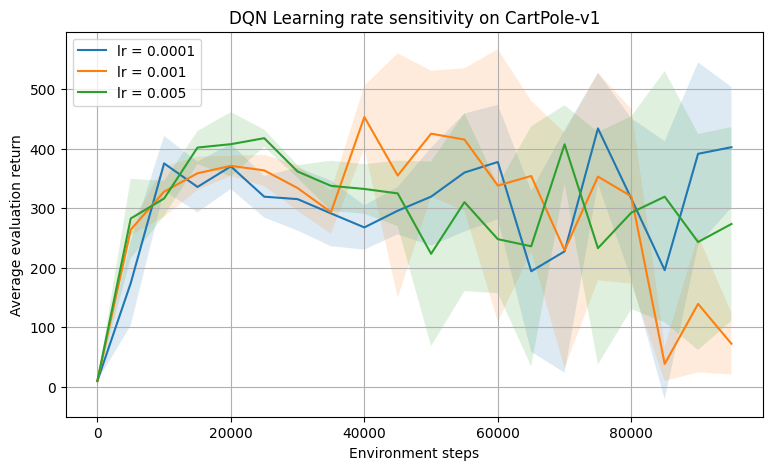



===== Gamma sensitivity on CartPole-v1 =====

========== Gamma: gamma = 0.95 ==========

===== Training with seed 0 =====
Step 0 | Eval return: 9.40 | Epsilon: 1.000
Step 5000 | Eval return: 447.30 | Epsilon: 0.850
Step 10000 | Eval return: 209.70 | Epsilon: 0.700
Step 15000 | Eval return: 212.90 | Epsilon: 0.550
Step 20000 | Eval return: 231.40 | Epsilon: 0.400
Step 25000 | Eval return: 300.70 | Epsilon: 0.250
Step 30000 | Eval return: 183.60 | Epsilon: 0.100
Step 35000 | Eval return: 162.90 | Epsilon: 0.100
Step 40000 | Eval return: 183.70 | Epsilon: 0.100
Step 45000 | Eval return: 134.90 | Epsilon: 0.100
Step 50000 | Eval return: 182.60 | Epsilon: 0.100
Step 55000 | Eval return: 176.70 | Epsilon: 0.100
Step 60000 | Eval return: 154.90 | Epsilon: 0.100
Step 65000 | Eval return: 159.60 | Epsilon: 0.100
Step 70000 | Eval return: 123.60 | Epsilon: 0.100
Step 75000 | Eval return: 293.10 | Epsilon: 0.100
Step 80000 | Eval return: 172.60 | Epsilon: 0.100
Step 85000 | Eval return: 190.70 

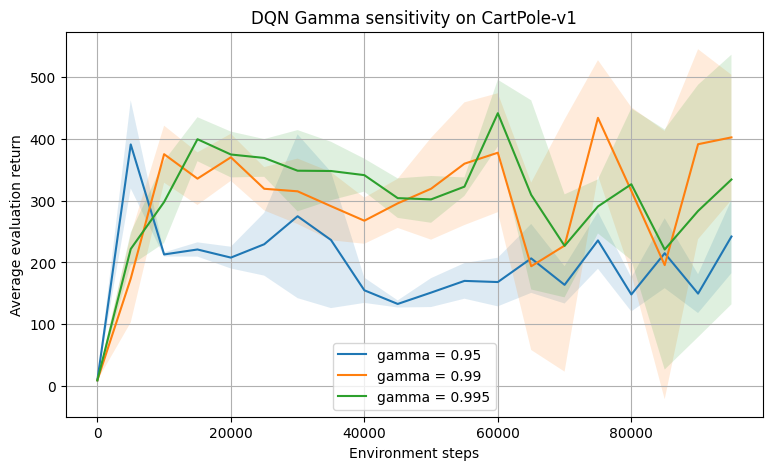



===== Epsilon decay sensitivity on CartPole-v1 =====

========== Epsilon decay: epsilon_decay_steps = 30000 ==========

===== Training with seed 0 =====
Step 0 | Eval return: 9.40 | Epsilon: 1.000
Step 5000 | Eval return: 269.60 | Epsilon: 0.850
Step 10000 | Eval return: 330.20 | Epsilon: 0.700
Step 15000 | Eval return: 276.60 | Epsilon: 0.550
Step 20000 | Eval return: 317.70 | Epsilon: 0.400
Step 25000 | Eval return: 270.90 | Epsilon: 0.250
Step 30000 | Eval return: 254.80 | Epsilon: 0.100
Step 35000 | Eval return: 264.70 | Epsilon: 0.100
Step 40000 | Eval return: 214.80 | Epsilon: 0.100
Step 45000 | Eval return: 245.90 | Epsilon: 0.100
Step 50000 | Eval return: 231.60 | Epsilon: 0.100
Step 55000 | Eval return: 295.90 | Epsilon: 0.100
Step 60000 | Eval return: 264.90 | Epsilon: 0.100
Step 65000 | Eval return: 25.00 | Epsilon: 0.100
Step 70000 | Eval return: 172.20 | Epsilon: 0.100
Step 75000 | Eval return: 500.00 | Epsilon: 0.100
Step 80000 | Eval return: 158.60 | Epsilon: 0.100
Ste

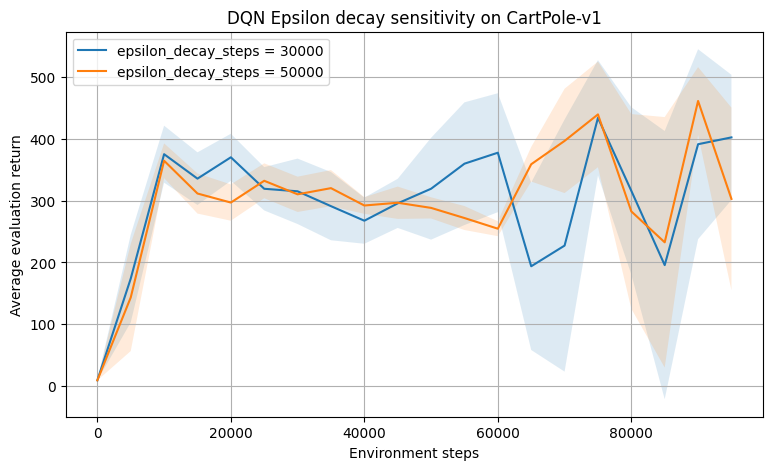



===== Network size sensitivity on CartPole-v1 =====

========== Network size: hidden_dim = 64 ==========

===== Training with seed 0 =====
Step 0 | Eval return: 9.50 | Epsilon: 1.000
Step 5000 | Eval return: 74.00 | Epsilon: 0.850
Step 10000 | Eval return: 327.70 | Epsilon: 0.700
Step 15000 | Eval return: 316.10 | Epsilon: 0.550
Step 20000 | Eval return: 297.00 | Epsilon: 0.400
Step 25000 | Eval return: 298.30 | Epsilon: 0.250
Step 30000 | Eval return: 231.60 | Epsilon: 0.100
Step 35000 | Eval return: 261.10 | Epsilon: 0.100
Step 40000 | Eval return: 255.60 | Epsilon: 0.100
Step 45000 | Eval return: 334.70 | Epsilon: 0.100
Step 50000 | Eval return: 487.10 | Epsilon: 0.100
Step 55000 | Eval return: 343.70 | Epsilon: 0.100
Step 60000 | Eval return: 253.20 | Epsilon: 0.100
Step 65000 | Eval return: 252.80 | Epsilon: 0.100
Step 70000 | Eval return: 114.80 | Epsilon: 0.100
Step 75000 | Eval return: 452.40 | Epsilon: 0.100
Step 80000 | Eval return: 156.20 | Epsilon: 0.100
Step 85000 | Eval

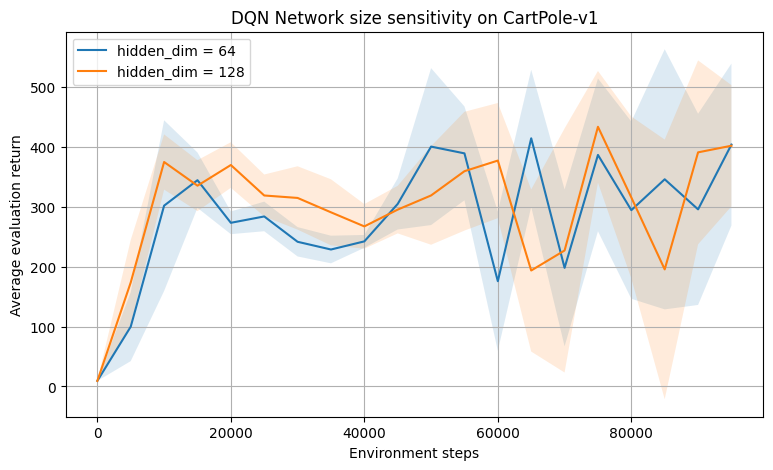



===== Replay buffer size sensitivity on CartPole-v1 =====

========== Replay buffer size: buffer_size = 10000 ==========

===== Training with seed 0 =====
Step 0 | Eval return: 9.40 | Epsilon: 1.000
Step 5000 | Eval return: 269.60 | Epsilon: 0.850
Step 10000 | Eval return: 342.40 | Epsilon: 0.700
Step 15000 | Eval return: 197.50 | Epsilon: 0.550
Step 20000 | Eval return: 260.80 | Epsilon: 0.400
Step 25000 | Eval return: 273.80 | Epsilon: 0.250
Step 30000 | Eval return: 327.70 | Epsilon: 0.100
Step 35000 | Eval return: 398.50 | Epsilon: 0.100
Step 40000 | Eval return: 383.60 | Epsilon: 0.100
Step 45000 | Eval return: 467.80 | Epsilon: 0.100
Step 50000 | Eval return: 500.00 | Epsilon: 0.100
Step 55000 | Eval return: 500.00 | Epsilon: 0.100
Step 60000 | Eval return: 500.00 | Epsilon: 0.100
Step 65000 | Eval return: 455.50 | Epsilon: 0.100
Step 70000 | Eval return: 500.00 | Epsilon: 0.100
Step 75000 | Eval return: 500.00 | Epsilon: 0.100
Step 80000 | Eval return: 500.00 | Epsilon: 0.100


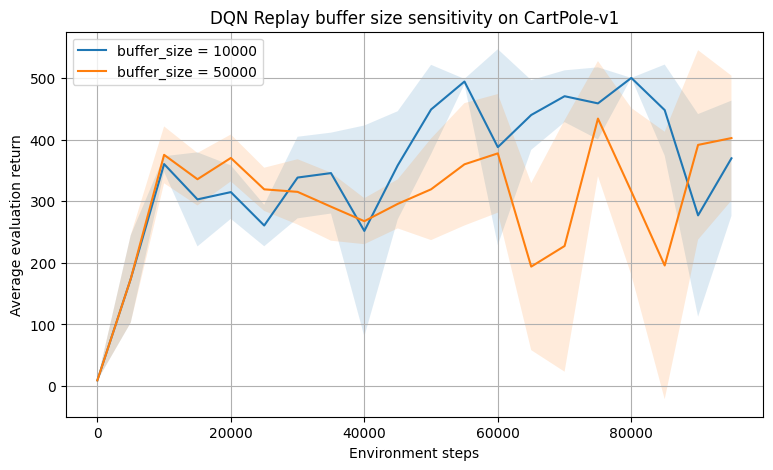


####################################################################################################
Running DQN experiments on Acrobot-v1
####################################################################################################
Number of configs: 6
Total runs: 18

========== DQN grid search: lr=0.0001, gamma=0.99, epsilon_decay_steps=30000, hidden_dim=128, buffer_size=50000 ==========

===== Training with seed 0 =====
Step 0 | Eval return: -500.00 | Epsilon: 1.000
Step 5000 | Eval return: -500.00 | Epsilon: 0.850
Step 10000 | Eval return: -86.50 | Epsilon: 0.700
Step 15000 | Eval return: -98.90 | Epsilon: 0.550
Step 20000 | Eval return: -87.80 | Epsilon: 0.400
Step 25000 | Eval return: -342.30 | Epsilon: 0.250
Step 30000 | Eval return: -84.50 | Epsilon: 0.100
Step 35000 | Eval return: -82.20 | Epsilon: 0.100
Step 40000 | Eval return: -83.00 | Epsilon: 0.100
Step 45000 | Eval return: -85.40 | Epsilon: 0.100
Step 50000 | Eval return: -87.00 | Epsilon: 0.100
Step 55000 | Eval

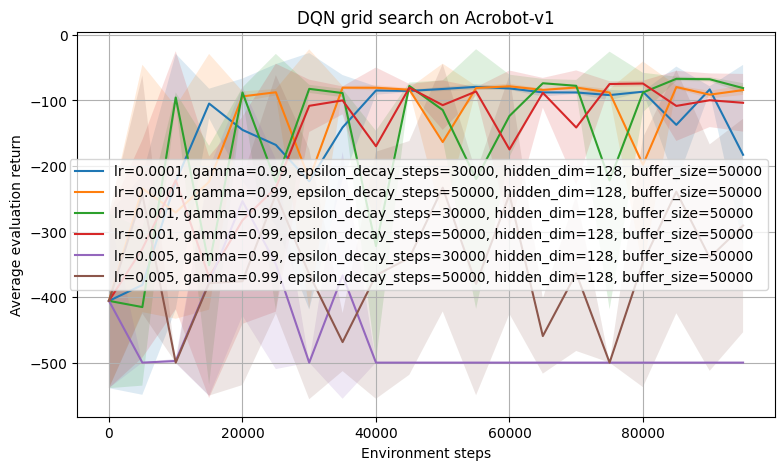


===== Training with seed 0 =====
Step 0 | Eval return: -500.00 | Epsilon: 1.000
Step 5000 | Eval return: -500.00 | Epsilon: 0.850
Step 10000 | Eval return: -101.50 | Epsilon: 0.700
Step 15000 | Eval return: -500.00 | Epsilon: 0.550
Step 20000 | Eval return: -77.70 | Epsilon: 0.400
Step 25000 | Eval return: -77.90 | Epsilon: 0.250
Step 30000 | Eval return: -75.20 | Epsilon: 0.100
Step 35000 | Eval return: -83.60 | Epsilon: 0.100
Step 40000 | Eval return: -384.30 | Epsilon: 0.100
Step 45000 | Eval return: -70.40 | Epsilon: 0.100
Step 50000 | Eval return: -178.60 | Epsilon: 0.100
Step 55000 | Eval return: -77.90 | Epsilon: 0.100
Step 60000 | Eval return: -82.30 | Epsilon: 0.100
Step 65000 | Eval return: -74.10 | Epsilon: 0.100
Step 70000 | Eval return: -79.00 | Epsilon: 0.100
Step 75000 | Eval return: -75.20 | Epsilon: 0.100
Step 80000 | Eval return: -66.90 | Epsilon: 0.100
Step 85000 | Eval return: -66.00 | Epsilon: 0.100
Step 90000 | Eval return: -71.60 | Epsilon: 0.100
Step 95000 | Ev

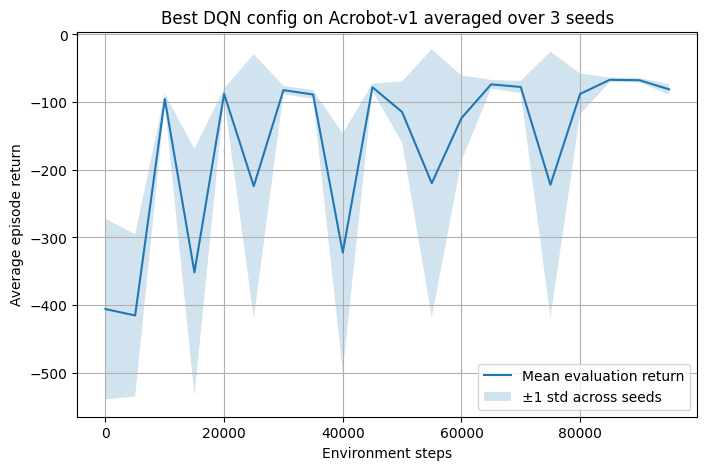

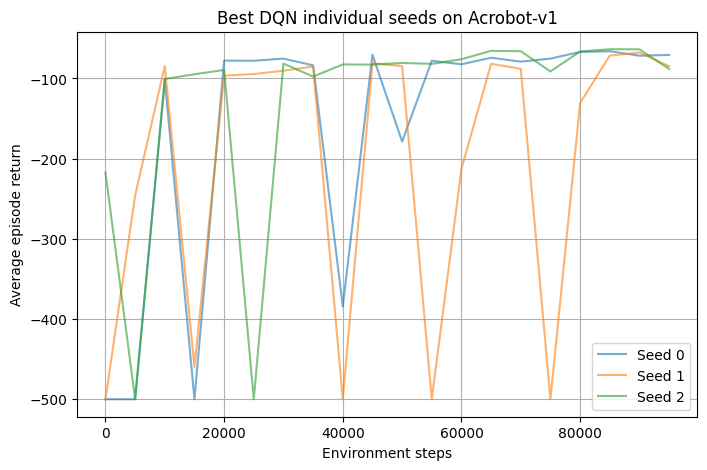



===== Learning rate sensitivity on Acrobot-v1 =====

========== Learning rate: lr = 0.0001 ==========

===== Training with seed 0 =====
Step 0 | Eval return: -500.00 | Epsilon: 1.000
Step 5000 | Eval return: -500.00 | Epsilon: 0.850
Step 10000 | Eval return: -86.50 | Epsilon: 0.700
Step 15000 | Eval return: -98.90 | Epsilon: 0.550
Step 20000 | Eval return: -87.80 | Epsilon: 0.400
Step 25000 | Eval return: -342.30 | Epsilon: 0.250
Step 30000 | Eval return: -84.50 | Epsilon: 0.100
Step 35000 | Eval return: -82.20 | Epsilon: 0.100
Step 40000 | Eval return: -83.00 | Epsilon: 0.100
Step 45000 | Eval return: -85.40 | Epsilon: 0.100
Step 50000 | Eval return: -87.00 | Epsilon: 0.100
Step 55000 | Eval return: -84.30 | Epsilon: 0.100
Step 60000 | Eval return: -84.80 | Epsilon: 0.100
Step 65000 | Eval return: -79.50 | Epsilon: 0.100
Step 70000 | Eval return: -84.50 | Epsilon: 0.100
Step 75000 | Eval return: -83.00 | Epsilon: 0.100
Step 80000 | Eval return: -87.20 | Epsilon: 0.100
Step 85000 | E

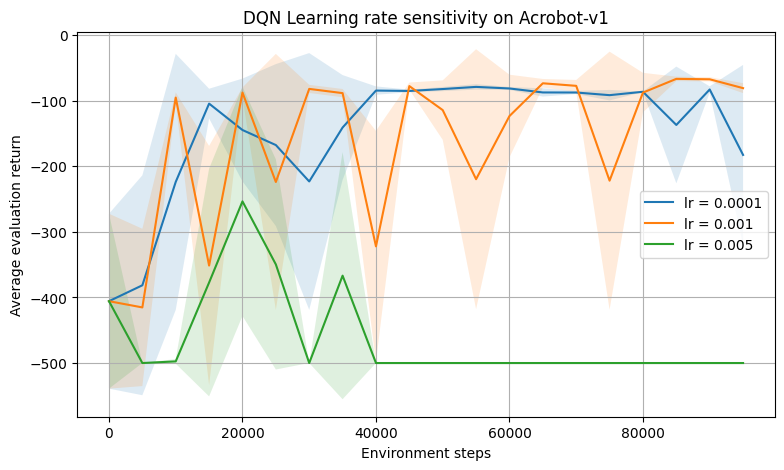



===== Gamma sensitivity on Acrobot-v1 =====

========== Gamma: gamma = 0.95 ==========

===== Training with seed 0 =====
Step 0 | Eval return: -500.00 | Epsilon: 1.000
Step 5000 | Eval return: -500.00 | Epsilon: 0.850
Step 10000 | Eval return: -500.00 | Epsilon: 0.700
Step 15000 | Eval return: -500.00 | Epsilon: 0.550
Step 20000 | Eval return: -254.20 | Epsilon: 0.400
Step 25000 | Eval return: -500.00 | Epsilon: 0.250
Step 30000 | Eval return: -500.00 | Epsilon: 0.100
Step 35000 | Eval return: -500.00 | Epsilon: 0.100
Step 40000 | Eval return: -500.00 | Epsilon: 0.100
Step 45000 | Eval return: -500.00 | Epsilon: 0.100
Step 50000 | Eval return: -500.00 | Epsilon: 0.100
Step 55000 | Eval return: -500.00 | Epsilon: 0.100
Step 60000 | Eval return: -500.00 | Epsilon: 0.100
Step 65000 | Eval return: -500.00 | Epsilon: 0.100
Step 70000 | Eval return: -132.00 | Epsilon: 0.100
Step 75000 | Eval return: -500.00 | Epsilon: 0.100
Step 80000 | Eval return: -123.00 | Epsilon: 0.100
Step 85000 | Ev

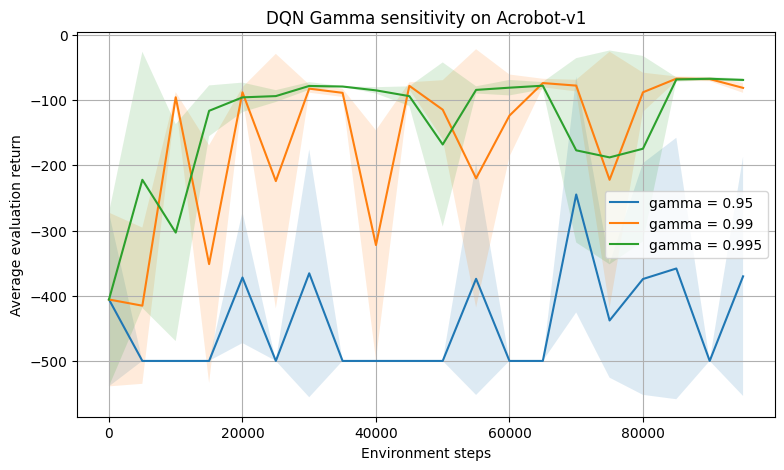



===== Epsilon decay sensitivity on Acrobot-v1 =====

========== Epsilon decay: epsilon_decay_steps = 30000 ==========

===== Training with seed 0 =====
Step 0 | Eval return: -500.00 | Epsilon: 1.000
Step 5000 | Eval return: -500.00 | Epsilon: 0.850
Step 10000 | Eval return: -101.50 | Epsilon: 0.700
Step 15000 | Eval return: -500.00 | Epsilon: 0.550
Step 20000 | Eval return: -77.70 | Epsilon: 0.400
Step 25000 | Eval return: -77.90 | Epsilon: 0.250
Step 30000 | Eval return: -75.20 | Epsilon: 0.100
Step 35000 | Eval return: -83.60 | Epsilon: 0.100
Step 40000 | Eval return: -384.30 | Epsilon: 0.100
Step 45000 | Eval return: -70.40 | Epsilon: 0.100
Step 50000 | Eval return: -178.60 | Epsilon: 0.100
Step 55000 | Eval return: -77.90 | Epsilon: 0.100
Step 60000 | Eval return: -82.30 | Epsilon: 0.100
Step 65000 | Eval return: -74.10 | Epsilon: 0.100
Step 70000 | Eval return: -79.00 | Epsilon: 0.100
Step 75000 | Eval return: -75.20 | Epsilon: 0.100
Step 80000 | Eval return: -66.90 | Epsilon: 0

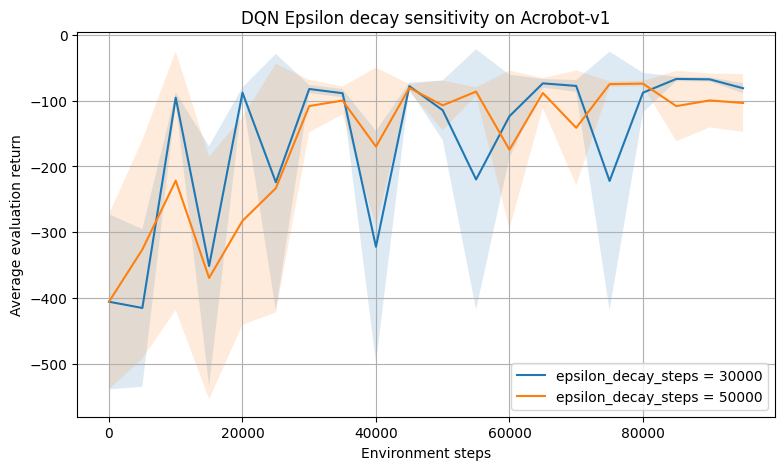



===== Network size sensitivity on Acrobot-v1 =====

========== Network size: hidden_dim = 64 ==========

===== Training with seed 0 =====
Step 0 | Eval return: -500.00 | Epsilon: 1.000
Step 5000 | Eval return: -500.00 | Epsilon: 0.850
Step 10000 | Eval return: -165.70 | Epsilon: 0.700
Step 15000 | Eval return: -91.20 | Epsilon: 0.550
Step 20000 | Eval return: -107.90 | Epsilon: 0.400
Step 25000 | Eval return: -76.80 | Epsilon: 0.250
Step 30000 | Eval return: -80.50 | Epsilon: 0.100
Step 35000 | Eval return: -81.80 | Epsilon: 0.100
Step 40000 | Eval return: -371.50 | Epsilon: 0.100
Step 45000 | Eval return: -500.00 | Epsilon: 0.100
Step 50000 | Eval return: -90.80 | Epsilon: 0.100
Step 55000 | Eval return: -75.00 | Epsilon: 0.100
Step 60000 | Eval return: -87.30 | Epsilon: 0.100
Step 65000 | Eval return: -109.00 | Epsilon: 0.100
Step 70000 | Eval return: -70.70 | Epsilon: 0.100
Step 75000 | Eval return: -500.00 | Epsilon: 0.100
Step 80000 | Eval return: -72.80 | Epsilon: 0.100
Step 85

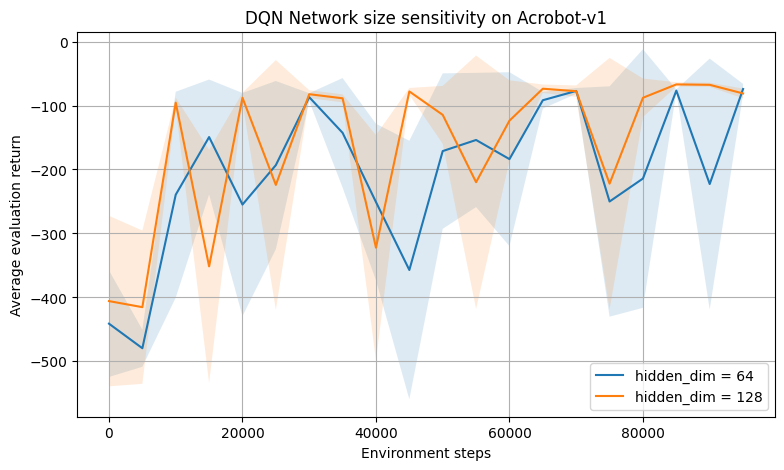



===== Replay buffer size sensitivity on Acrobot-v1 =====

========== Replay buffer size: buffer_size = 10000 ==========

===== Training with seed 0 =====
Step 0 | Eval return: -500.00 | Epsilon: 1.000
Step 5000 | Eval return: -500.00 | Epsilon: 0.850
Step 10000 | Eval return: -500.00 | Epsilon: 0.700
Step 15000 | Eval return: -500.00 | Epsilon: 0.550
Step 20000 | Eval return: -500.00 | Epsilon: 0.400
Step 25000 | Eval return: -464.00 | Epsilon: 0.250
Step 30000 | Eval return: -77.60 | Epsilon: 0.100
Step 35000 | Eval return: -500.00 | Epsilon: 0.100
Step 40000 | Eval return: -337.40 | Epsilon: 0.100
Step 45000 | Eval return: -71.40 | Epsilon: 0.100
Step 50000 | Eval return: -77.30 | Epsilon: 0.100
Step 55000 | Eval return: -80.10 | Epsilon: 0.100
Step 60000 | Eval return: -149.10 | Epsilon: 0.100
Step 65000 | Eval return: -71.10 | Epsilon: 0.100
Step 70000 | Eval return: -71.80 | Epsilon: 0.100
Step 75000 | Eval return: -67.50 | Epsilon: 0.100
Step 80000 | Eval return: -76.70 | Epsil

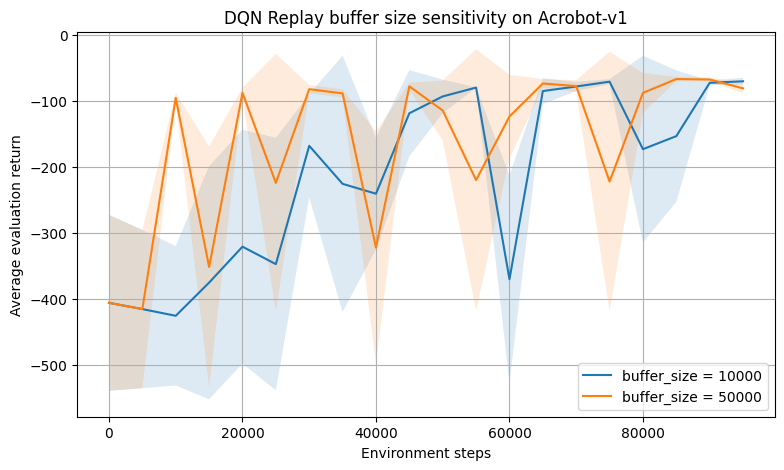

In [32]:
DQN_ENV_KEYS = ["cartpole", "acrobot"]
seeds = [0, 1, 2]

all_env_results = {}

for ENV_KEY in DQN_ENV_KEYS:
    ENV_NAME = ENVIRONMENTS[ENV_KEY]

    print("\n" + "#" * 100)
    print(f"Running DQN experiments on {ENV_NAME}")
    print("#" * 100)

    env_result_dir = RESULTS_DIR / ENV_NAME
    env_result_dir.mkdir(parents=True, exist_ok=True)

    base_config = make_config(
        total_steps=100_000,
        eval_interval=5_000,
        eval_episodes=10,
        batch_size=32,
        buffer_size=50_000,
        gamma=0.99,
        lr=1e-3,
        epsilon_start=1.0,
        epsilon_end=0.1,
        epsilon_decay_steps=30_000,
        hidden_dim=128,
        learning_starts=1_000,
        eval_epsilon=0.00
    )

    grid = {
        "lr": [1e-4, 1e-3, 5e-3],
        "gamma": [0.99],
        "epsilon_decay_steps": [30_000, 50_000],
        "hidden_dim": [128],
        "buffer_size": [50_000],
    }

    grid_configs = build_config_grid(base_config, grid)

    print("Number of configs:", len(grid_configs))
    print("Total runs:", len(grid_configs) * len(seeds))

    grid_results = run_hyperparameter_comparison(
        env_name=ENV_NAME,
        experiment_name="DQN grid search",
        configs=grid_configs,
        seeds=seeds
    )

    save_pickle(
        remove_networks_from_results(grid_results),
        env_result_dir / "grid_results_raw.pkl"
    )

    grid_summary = summarize_results(grid_results)
    grid_summary_df = pd.DataFrame(grid_summary)
    grid_summary_df.to_csv(
        env_result_dir / "grid_summary.csv",
        index=False
    )

    for row in grid_summary[:10]:
        print(
            f"{row['config']:90s} | "
            f"final = {row['final_mean']:.2f} ± {row['final_std']:.2f} | "
            f"best = {row['best_mean_during_training']:.2f}"
        )

    best_label = grid_summary[0]["config"]
    best_config = grid_results[best_label]["config"]

    print("\nBest config:")
    print(best_label)
    print(best_config)

    save_json(
        asdict(best_config),
        env_result_dir / "best_config.json"
    )

    plot_hyperparameter_comparison(
        grid_results,
        title=f"DQN grid search on {ENV_NAME}",
        save_path=env_result_dir / "grid_search_curve.png"
    )

    best_results = run_multiple_seeds(
        env_name=ENV_NAME,
        config=best_config,
        seeds=seeds
    )

    best_steps, best_eval_matrix = extract_eval_curves(best_results)
    best_mean, best_std = compute_statistics(best_eval_matrix)

    save_pickle(
        best_results,
        env_result_dir / "best_results_raw.pkl"
    )

    save_eval_curve_csv(
        steps=best_steps,
        eval_matrix=best_eval_matrix,
        mean=best_mean,
        std=best_std,
        path=env_result_dir / "best_eval_curve.csv"
    )

    for seed, result in zip(seeds, best_results):
        save_trained_model(
            result["q_network"],
            env_result_dir / f"q_network_seed_{seed}.pt"
        )

    plot_eval_curve(
        best_steps,
        best_mean,
        best_std,
        title=f"Best DQN config on {ENV_NAME} averaged over {len(seeds)} seeds",
        save_path=env_result_dir / "best_eval_curve.png"
    )

    plot_individual_seed_curves(
        best_steps,
        best_eval_matrix,
        title=f"Best DQN individual seeds on {ENV_NAME}",
        save_path=env_result_dir / "individual_seed_curves.png"
    )

    sensitivity_experiments = {
        "Learning rate": ("lr", [1e-4, 1e-3, 5e-3]),
        "Gamma": ("gamma", [0.95, 0.99, 0.995]),
        "Epsilon decay": ("epsilon_decay_steps", [30_000, 50_000]),
        "Network size": ("hidden_dim", [64, 128]),
        "Replay buffer size": ("buffer_size", [10_000, 50_000]),
    }

    sensitivity_results = {}

    for experiment_name, (param_name, values) in sensitivity_experiments.items():
        print(f"\n\n===== {experiment_name} sensitivity on {ENV_NAME} =====")

        configs = make_variation_configs(best_config, param_name, values)

        results = run_hyperparameter_comparison(
            env_name=ENV_NAME,
            experiment_name=experiment_name,
            configs=configs,
            seeds=seeds
        )

        sensitivity_results[experiment_name] = results

        safe_experiment_name = experiment_name.lower().replace(" ", "_")

        save_pickle(
            remove_networks_from_results(results),
            env_result_dir / f"sensitivity_{safe_experiment_name}_raw.pkl"
        )

        summary = summarize_results(results)
        pd.DataFrame(summary).to_csv(
            env_result_dir / f"sensitivity_{safe_experiment_name}_summary.csv",
            index=False
        )

        plot_hyperparameter_comparison(
            results,
            title=f"DQN {experiment_name} sensitivity on {ENV_NAME}",
            save_path=env_result_dir / f"sensitivity_{safe_experiment_name}_curve.png"
        )

    cleaned_sensitivity_results = {}

    for experiment_name, results in sensitivity_results.items():
        cleaned_sensitivity_results[experiment_name] = remove_networks_from_results(results)

    save_pickle(
        cleaned_sensitivity_results,
        env_result_dir / "all_sensitivity_results_raw.pkl"
    )

    all_env_results[ENV_NAME] = {
        "grid_summary": grid_summary,
        "best_config": best_config,
        "best_steps": best_steps,
        "best_eval_matrix": best_eval_matrix,
        "best_mean": best_mean,
        "best_std": best_std,
    }